In [1]:
import pickle
import re
import sys
from pathlib import Path

import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scanpy as sc
import seaborn as sns
from scipy.stats import norm

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject
from MixedEffectsModeling.core.pathway_convergence import overlap_enrichment

ZDIR = Path('./Z_scores_mixed')
PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PCDIR.mkdir(parents=True, exist_ok=True)
PFDIR.mkdir(parents=True, exist_ok=True)
PP = config.PATHWAY_CONV_PARAMS

PHENOTYPE = 'Pancreatic Cancer'
PDIR = PCDIR / PHENOTYPE.replace(' ', '_')
PDIR.mkdir(parents=True, exist_ok=True)

In [ ]:
PCDIR = config.PATHWAY_CONV_DIR
JACC_PATH = ZDIR / 'gene_pathway_overlap_enrichment.csv'

if JACC_PATH.exists():
    jacc_summary = pd.read_csv(JACC_PATH)
else:
    rows = []
    for pdir in sorted(d for d in PCDIR.iterdir() if d.is_dir() and (d / 'sig.pkl').exists()):
        d = pickle.load(open(pdir / 'sig.pkl', 'rb'))
        if d['gene_sig'].shape[0] < 3:
            continue    
        ge = overlap_enrichment(d['gene_sig'], n_perm=200)
        pe = overlap_enrichment(d['path_sig'], n_perm=200)
        rows.append(dict(study_dir=pdir.name, n_pat=d['gene_sig'].shape[0],
                         gene_obs=ge['obs_median'], gene_null=ge['null_median'],
                         gene_ratio=ge['enrichment_ratio'], gene_perm_p=ge['perm_pvalue'],
                         path_obs=pe['obs_median'], path_null=pe['null_median'],
                         path_ratio=pe['enrichment_ratio'], path_perm_p=pe['perm_pvalue']))
    jacc_summary = pd.DataFrame(rows)
    jacc_summary.to_csv(JACC_PATH, index=False)

display(jacc_summary)
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

CROSS_PATH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark' / 'cross_study_replication.csv'
if CROSS_PATH.exists():
    cross_df = pd.read_csv(CROSS_PATH)
else:
    cross_df = dc.cross_study_replication()
    cross_df.to_csv(CROSS_PATH, index=False)

display(cross_df)

In [3]:
# 0. Load cohort (reuse 3_disease_scoring.ipynb cache)
Z = np.load(ZDIR / 'Z_disease_shash.npy')
gene_names = pickle.load(open(ZDIR / 'gene_names.pkl', 'rb'))
meta = pd.read_csv(ZDIR / 'sample_meta.csv')

cohort_mask = (meta['phenotype'] == PHENOTYPE) & meta['ood_keep']
idx = np.where(cohort_mask.values)[0]
names_c = meta['sample'].values[idx]
Zc = Z[idx]
n_pat = len(idx)

In [ ]:
UNIV_PATH = PCDIR / 'universe.pkl'
if UNIV_PATH.exists():
    universe_syms, sym2idx, Zu, Fm = pickle.load(open(UNIV_PATH, 'rb'))
else:
    sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
    syms_all = sym_of.values
    universe_syms = pd.unique(syms_all[sym_of.notna().values])
    sym2idx = {s: i for i, s in enumerate(universe_syms)}
    N = len(universe_syms)
    col2sym = np.array([sym2idx.get(s, -1) if pd.notna(s) else -1 for s in syms_all])
    keep_cols = col2sym >= 0
    Zc_v, sym_idx_v = Zc[:, keep_cols], col2sym[keep_cols]

    sum_mat, finite_cnt = np.zeros((n_pat, N)), np.zeros((n_pat, N))
    for i in range(n_pat):
        np.add.at(sum_mat[i], sym_idx_v, np.nan_to_num(Zc_v[i], nan=0.0))
        np.add.at(finite_cnt[i], sym_idx_v, np.isfinite(Zc_v[i]).astype(float))
    Zu_raw = np.divide(sum_mat, finite_cnt, out=np.full_like(sum_mat, np.nan), where=finite_cnt > 0)
    Zu = np.nan_to_num(Zu_raw, nan=0.0)
    Fm = np.isfinite(Zu_raw).astype(float)
    pickle.dump((universe_syms, sym2idx, Zu, Fm), open(UNIV_PATH, 'wb'))

N = len(universe_syms)

LIB_PATH = PCDIR / 'gene_set_matrix.pkl'
if LIB_PATH.exists():
    terms_raw, M_raw = pickle.load(open(LIB_PATH, 'rb'))
else:
    libs = {}
    for lib in PP['gene_sets']:
        libs.update(gp.get_library(lib, organism='human'))
    terms_raw = list(libs.keys())
    M_raw = np.zeros((len(terms_raw), N), dtype=bool)
    for ti, t in enumerate(terms_raw):
        for g in libs[t]:
            j = sym2idx.get(g)
            if j is not None:
                M_raw[ti, j] = True
    keep = M_raw.sum(axis=1) >= PP['min_pathway_size']
    terms_raw, M_raw = [t for t, k in zip(terms_raw, keep) if k], M_raw[keep]
    pickle.dump((terms_raw, M_raw), open(LIB_PATH, 'wb'))

universe: 19831 gene symbols, 2063 pathways after housekeeping exclusion (68 dropped of 2131)


In [7]:
# 3. Per-patient/per-pathway mean-Z + per-patient permutation null (K=200, ~2min) -- cache-first
NULL_PATH = PDIR / 'null.npz'
Mf = M.astype(float)

if NULL_PATH.exists():
    d = np.load(NULL_PATH)
    T, null_mean, null_sd = d['T'], d['null_mean'], d['null_sd']
else:
    num, den = (Zu * Fm) @ Mf.T, Fm @ Mf.T
    T = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

    rng = np.random.default_rng(PP['seed'])
    null_sum, null_sumsq = np.zeros_like(T), np.zeros_like(T)
    for _ in range(PP['n_null_perm']):
        perm = rng.permutation(N)
        Zp, Fp = Zu[:, perm], Fm[:, perm]
        nu, de = (Zp * Fp) @ Mf.T, Fp @ Mf.T
        Tn = np.divide(nu, de, out=np.zeros_like(nu), where=de > 0)
        null_sum += Tn
        null_sumsq += Tn ** 2
    null_mean = null_sum / PP['n_null_perm']
    null_sd = np.sqrt(np.clip(null_sumsq / PP['n_null_perm'] - null_mean ** 2, 1e-12, None))
    np.savez(NULL_PATH, T=T, null_mean=null_mean, null_sd=null_sd)

Tz = (T - null_mean) / null_sd
p_path = 2 * norm.sf(np.abs(Tz))
path_sig = np.zeros_like(p_path, dtype=bool)
for i in range(n_pat):
    path_sig[i] = bh_fdr_reject(p_path[i], q=PP['fdr_q'])

n_path_sig = path_sig.sum(axis=1)
path_jacc, path_ovc = pairwise_overlap(path_sig)

print(f"sig pathways/patient: min={n_path_sig.min()} median={np.median(n_path_sig):.0f} max={n_path_sig.max()}  "
      f"(zero: {(n_path_sig == 0).sum()}/{n_pat})")
print(f"PATHWAY-level pairwise Jaccard: mean={path_jacc.mean():.4f} median={np.median(path_jacc):.4f}")
print(f"ratio vs gene-level mean Jaccard: {path_jacc.mean() / gene_jacc.mean():.1f}x")

sig pathways/patient: min=0 median=12 max=357  (zero: 11/72)
PATHWAY-level pairwise Jaccard: mean=0.0346 median=0.0000
ratio vs gene-level mean Jaccard: 13.1x


In [8]:
import cairosvg
from MixedEffectsModeling.core.pathway_convergence import (
    load_pathway_library, load_symbol_vocab, match_pathway_index, parse_selected_pathways,
    slugify, strip_reactome_code,
)

PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PFDIR.mkdir(parents=True, exist_ok=True)

# ME/CFS dropped -- literature review found only one weakly-supported pathway. Liver Cancer split
# into its 2 constituent studies instead of pooled (see run_pathway_convergence_batch.py) -- each
# gets its own Sankey since pooling blended 3 different studies' technical variance
PHENOTYPES = [
    'Tuberculosis', 'Pancreatitis', 'Pancreatic Cancer', 'Pre-eclampsia',
    'Liver Cancer (Roskams-Hieter B et al.)', 'Liver Cancer (Chen et al.)',
    'Colorectal Cancer', 'Lung Cancer', 'Esophagus Cancer', 'Stomach Cancer',
]

# only Pancreatic Cancer has a severity/subtype column in this cohort (see 4_gene_enrichment.ipynb
# sec. 7) -- everyone else gets a single neutral patient color
SEVERITY_COL = 'Stage/Condition'
SEVERITY_COLORS = {'PDAC': '#d55e00', 'IPMN': '#0072b2', 'Islet Cell Tumor': '#009e73'}
DEFAULT_PATIENT_COLOR = "#737373"

EDGE_Z_MIN = 1.75
MAX_GENES_PER_PATHWAY = 15
HISTONE_FAMILY_CAP = 2
histone_rx = re.compile(r'^(H1|H2A|H2B|H3|H4)')


def gene_family(sym):
    m = histone_rx.match(sym)
    return m.group(1) if m else sym


def hex_to_rgba(hex_str, a):
    r, g, b = (int(hex_str.lstrip('#')[k:k + 2], 16) for k in (0, 2, 4))
    return f'rgba({r},{g},{b},{a})'


def build_sankey(phenotype, universe_syms, terms, M):
    slug = slugify(phenotype)
    pdir = PCDIR / slug
    review_path = pdir / 'pathway_literature_review.md'
    if not review_path.exists():
        print(f'{phenotype}: no literature review found, skipping')
        return

    names = parse_selected_pathways(review_path)
    top_idx, missing = [], []
    for name in names:
        j = match_pathway_index(name, terms)
        (top_idx if j is not None else missing).append(j if j is not None else name)
    if missing:
        print(f'{phenotype}: could not match {missing} to a pathway term, skipping those')
    if not top_idx:
        print(f'{phenotype}: no matched pathways, skipping')
        return

    d = pickle.load(open(pdir / 'sig.pkl', 'rb'))
    path_sig, Tz = d['path_sig'], d['Tz']
    Zu, Fm = pickle.load(open(pdir / 'universe.pkl', 'rb'))
    n_pat = path_sig.shape[0]

    if phenotype == 'Pancreatic Cancer':
        names_c = d['names_c']
        severity = sc.read_h5ad(config.H5AD_PATH, backed='r').obs[SEVERITY_COL].reindex(names_c).values
        pat_color = lambda i: SEVERITY_COLORS.get(severity[i], '#999999')
    else:
        pat_color = lambda i: DEFAULT_PATIENT_COLOR

    PATH_COLORS = [f'#{"".join(f"{int(c * 255):02x}" for c in plt.get_cmap("tab10")(k)[:3])}'
                   for k in range(len(top_idx))]

    pathway_gene_edges = {pi: {} for pi in range(len(top_idx))}
    for pi, j in enumerate(top_idx):
        members = np.where(M[j])[0]
        pats = np.where(path_sig[:, j])[0]
        if len(pats) == 0 or len(members) == 0:
            continue
        sub = Zu[np.ix_(pats, members)]
        qual = np.abs(sub) >= EDGE_Z_MIN
        gcols_all = np.where(qual.any(axis=0))[0]
        if len(gcols_all) == 0:
            continue
        deg = qual[:, gcols_all].sum(axis=0)
        strength = np.where(qual[:, gcols_all], np.abs(sub[:, gcols_all]), 0).sum(axis=0)
        ranked = gcols_all[np.lexsort((-strength, -deg))]
        gcols, family_count = [], {}
        for gc in ranked:
            fam = gene_family(universe_syms[members[gc]])
            if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
                continue
            gcols.append(gc)
            family_count[fam] = family_count.get(fam, 0) + 1
            if len(gcols) == MAX_GENES_PER_PATHWAY:
                break
        for gc in gcols:
            gu = members[gc]
            pathway_gene_edges[pi][gu] = {pats[k]: sub[k, gc] for k in range(len(pats)) if abs(sub[k, gc]) >= EDGE_Z_MIN}

    gene_strength = {}
    for pi, edges_by_gene in pathway_gene_edges.items():
        for gu, edges in edges_by_gene.items():
            gene_strength.setdefault(gu, {})[pi] = sum(abs(z) for z in edges.values())
    if not gene_strength:
        print(f'{phenotype}: no gene edges survived EDGE_Z_MIN, skipping')
        return
    gene_primary_pi = {gu: max(dd, key=dd.get) for gu, dd in gene_strength.items()}
    displayed_genes = sorted(gene_strength,
                             key=lambda gu: (gene_primary_pi[gu], -gene_strength[gu][gene_primary_pi[gu]]))

    pat_gene_z = {}
    for edges_by_gene in pathway_gene_edges.values():
        for gu, edges in edges_by_gene.items():
            for i, z in edges.items():
                pat_gene_z[(i, gu)] = abs(z)
    displayed_pats = sorted({i for i, _ in pat_gene_z})

    n_pat_d, n_gene_d, n_path_d = len(displayed_pats), len(displayed_genes), len(top_idx)
    pat_pos = {i: k for k, i in enumerate(displayed_pats)}
    gene_pos = {gu: k for k, gu in enumerate(displayed_genes)}

    node_labels = ([f'patient {i}' for i in displayed_pats] + [universe_syms[gu] for gu in displayed_genes]
                  + [strip_reactome_code(terms[j]) for j in top_idx])
    node_colors = ([pat_color(i) for i in displayed_pats]
                  + [PATH_COLORS[gene_primary_pi[gu]] for gu in displayed_genes]
                  + PATH_COLORS)

    src, tgt, val, link_col = [], [], [], []
    for (i, gu), z in pat_gene_z.items():
        src.append(pat_pos[i])
        tgt.append(n_pat_d + gene_pos[gu])
        val.append(z)
        link_col.append(hex_to_rgba(pat_color(i), 0.35))
    for pi, edges_by_gene in pathway_gene_edges.items():
        for gu, edges in edges_by_gene.items():
            src.append(n_pat_d + gene_pos[gu])
            tgt.append(n_pat_d + n_gene_d + pi)
            val.append(sum(abs(z) for z in edges.values()))
            link_col.append(hex_to_rgba(PATH_COLORS[pi], 0.45))

    fig = go.Figure(go.Sankey(
        arrangement='snap',
        node=dict(label=node_labels, color=node_colors, pad=3, thickness=10, line=dict(width=0)),
        link=dict(source=src, target=tgt, value=val, color=link_col),
    ))
    fig.update_layout(width=1000, height=max(900, (n_pat_d + n_gene_d) * 12), font_size=11, title=f'{phenotype} pathway convergence')

    # plotly.js hardcodes a white text-shadow halo on Sankey node labels -- strip it via SVG post-process
    svg = fig.to_image(format='svg').decode('utf-8')
    svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
    out_path = PFDIR / f'{slug}_pathway_convergence_sankey.png'
    cairosvg.svg2png(bytestring=svg.encode('utf-8'), write_to=str(out_path), scale=2)
    print(f'{phenotype}: {n_pat_d} patients, {n_gene_d} genes, {n_path_d} pathways -> {out_path}')


if __name__ == '__main__':
    universe_syms, sym2idx, _ = load_symbol_vocab(None)
    terms, M = load_pathway_library()
    for ph in PHENOTYPES:
        build_sankey(ph, universe_syms, terms, M)


/tmp/ipykernel_58688/915718684.py:152: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


Tuberculosis: 92 patients, 70 genes, 6 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Tuberculosis_pathway_convergence_sankey.png
Pancreatitis: 28 patients, 44 genes, 3 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pancreatitis_pathway_convergence_sankey.png


/tmp/ipykernel_58688/915718684.py:152: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


Pancreatic Cancer: 41 patients, 77 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pancreatic_Cancer_pathway_convergence_sankey.png
Pre-eclampsia: 30 patients, 105 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pre-eclampsia_pathway_convergence_sankey.png
Liver Cancer (Roskams-Hieter B et al.): 22 patients, 88 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Liver_Cancer_(Roskams-Hieter_B_et_al.)_pathway_convergence_sankey.png
Liver Cancer (Chen et al.): 10 patients, 85 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Liver_Cancer_(Chen_et_al.)_pathway_convergence_sankey.png
Colorectal Cancer: 29 patients, 39 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Colorectal_Cancer_pathway_convergence_sankey.png
Lung Cancer: 21 p

## 8. Pancreatic cohort subtype divergence

PDAC / IPMN / Islet Cell Tumor (Pancreatic Cancer subtypes) and Acute Pancreatitis all come from the
same single-study cohort (Moore et al._Batch_1). The 3 neoplastic/pre-neoplastic subtypes each
converge on their own distinct pathway; Acute Pancreatitis does not converge on anything specific to
it -- its own top pathways are shared, at equal-or-higher rate, by the tumor subtypes too.

In [9]:
# 8. Pancreatic cohort subtype divergence: PDAC / IPMN / Islet Cell Tumor / Acute Pancreatitis all
# come from the same batch (Moore et al._Batch_1), confirmed directly against meta -- a genuine
# within-study subtype comparison, not a cross-study confound like the Liver Cancer split.
SUBTYPE_COLORS = {'PDAC': '#d55e00', 'IPMN': '#0072b2', 'Islet Cell Tumor': '#009e73', 'Pancreatitis': '#737373'}

dpc = pickle.load(open(PCDIR / 'Pancreatic_Cancer' / 'sig.pkl', 'rb'))
dpt = pickle.load(open(PCDIR / 'Pancreatitis' / 'sig.pkl', 'rb'))
assert dpc['terms'] == dpt['terms']

severity_pc = sc.read_h5ad(config.H5AD_PATH, backed='r').obs['Stage/Condition'].reindex(dpc['names_c']).astype(str).values
subtype_labels = np.concatenate([severity_pc, np.full(len(dpt['names_c']), 'Pancreatitis')])
subtype_path_sig = np.vstack([dpc['path_sig'], dpt['path_sig']])
print(pd.Series(subtype_labels).value_counts())
subtype_groups = ['PDAC', 'IPMN', 'Islet Cell Tumor', 'Pancreatitis']
rate = pd.DataFrame({g: subtype_path_sig[subtype_labels == g].mean(axis=0) for g in subtype_groups}, index=dpc['terms'])
spec = pd.DataFrame({g: rate[g] - rate.drop(columns=g).max(axis=1) for g in subtype_groups})

print("\ntop specificity per subtype (rate in group minus max rate among the other 3):")
for g in subtype_groups:
    top = spec[g].sort_values(ascending=False).head(10)
    for t, v in top.items():
        print(f"  {g} {strip_reactome_code(t)} spec={v:.2f}")

Pancreatitis        79
PDAC                37
IPMN                27
Islet Cell Tumor     8
Name: count, dtype: int64

top specificity per subtype (rate in group minus max rate among the other 3):
  PDAC Regulation Of Complement Cascade spec=0.18
  PDAC Biological Oxidations spec=0.18
  PDAC Post-translational Protein Phosphorylation spec=0.17
  PDAC Complement and coagulation cascades spec=0.17
  PDAC Chylomicron Remodeling spec=0.15
  PDAC Complement Cascade spec=0.15
  PDAC Retinoid Metabolism And Transport spec=0.15
  PDAC Formation Of Fibrin Clot (Clotting Cascade) spec=0.15
  PDAC Metabolism of xenobiotics by cytochrome P450 spec=0.15
  PDAC Metabolism Of Fat-Soluble Vitamins spec=0.15
  IPMN Assembly Of Collagen Fibrils And Other Multimeric Structures spec=0.12
  IPMN G2/M Transition spec=0.11
  IPMN Mitotic G2-G2/M Phases spec=0.11
  IPMN RHO GTPases Activate PKNs spec=0.08
  IPMN Ub-specific Processing Proteases spec=0.08
  IPMN Collagen Degradation spec=0.07
  IPMN Repression

In [10]:
SUBTYPE_PATHWAYS = {
    'PDAC': ['Regulation Of IGF Transport And Uptake By IGFBPs'],
    'IPMN': ['Mitotic G2-G2/M Phases', 'Repression Of WNT Target Genes','Diseases Of Programmed Cell Death'],
    'Islet Cell Tumor': ['Cdc20:Phospho-APC/C Mediated Degradation Of Cyclin A','Regulation Of PTEN Stability And Activity'],  # n=8, interpret cautiously
}
SHARED_PATHWAYS = ['Neutrophil Degranulation', 'Innate Immune System']  # Pancreatitis's own top-rate
# pathways -- included to show it converges on the same generic pathway as everyone else, not a
# distinct one, which is the point of this figure

Zu_pc, Fm_pc = pickle.load(open(PCDIR / 'Pancreatic_Cancer' / 'universe.pkl', 'rb'))
Zu_pt, Fm_pt = pickle.load(open(PCDIR / 'Pancreatitis' / 'universe.pkl', 'rb'))
subtype_Zu = np.vstack([Zu_pc, Zu_pt])

pathway_specs = [(name, owner) for owner, names in SUBTYPE_PATHWAYS.items() for name in names]
pathway_specs += [(name, 'shared') for name in SHARED_PATHWAYS]
subtype_top_idx = [match_pathway_index(name, terms) for name, _ in pathway_specs]
subtype_owner = [owner for _, owner in pathway_specs]
assert all(j is not None for j in subtype_top_idx), pathway_specs

SUBTYPE_PATH_COLORS = [SUBTYPE_COLORS.get(o, '#bbbbbb') for o in subtype_owner]

pathway_gene_edges = {pi: {} for pi in range(len(subtype_top_idx))}
for pi, j in enumerate(subtype_top_idx):
    members = np.where(M[j])[0]
    pats = np.where(subtype_path_sig[:, j])[0]
    if len(pats) == 0 or len(members) == 0:
        continue
    sub = subtype_Zu[np.ix_(pats, members)]
    qual = np.abs(sub) >= EDGE_Z_MIN
    gcols_all = np.where(qual.any(axis=0))[0]
    if len(gcols_all) == 0:
        continue
    deg = qual[:, gcols_all].sum(axis=0)
    strength = np.where(qual[:, gcols_all], np.abs(sub[:, gcols_all]), 0).sum(axis=0)
    ranked = gcols_all[np.lexsort((-strength, -deg))]
    gcols, family_count = [], {}
    for gc in ranked:
        fam = gene_family(universe_syms[members[gc]])
        if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
            continue
        gcols.append(gc)
        family_count[fam] = family_count.get(fam, 0) + 1
        if len(gcols) == MAX_GENES_PER_PATHWAY:
            break
    for gc in gcols:
        gu = members[gc]
        pathway_gene_edges[pi][gu] = {pats[k]: sub[k, gc] for k in range(len(pats)) if abs(sub[k, gc]) >= EDGE_Z_MIN}

gene_strength = {}
for pi, edges_by_gene in pathway_gene_edges.items():
    for gu, edges in edges_by_gene.items():
        gene_strength.setdefault(gu, {})[pi] = sum(abs(z) for z in edges.values())
gene_primary_pi = {gu: max(dd, key=dd.get) for gu, dd in gene_strength.items()}
displayed_genes = sorted(gene_strength, key=lambda gu: (gene_primary_pi[gu], -gene_strength[gu][gene_primary_pi[gu]]))

pat_gene_z = {}
for edges_by_gene in pathway_gene_edges.values():
    for gu, edges in edges_by_gene.items():
        for i, z in edges.items():
            pat_gene_z[(i, gu)] = abs(z)
displayed_pats = sorted({i for i, _ in pat_gene_z}, key=lambda i: (subtype_labels[i], i))

n_pat_d, n_gene_d, n_path_d = len(displayed_pats), len(displayed_genes), len(subtype_top_idx)
pat_pos = {i: k for k, i in enumerate(displayed_pats)}
gene_pos = {gu: k for k, gu in enumerate(displayed_genes)}

node_labels = ([f'{subtype_labels[i]} #{i}' for i in displayed_pats] + [universe_syms[gu] for gu in displayed_genes]
              + [strip_reactome_code(terms[j]) for j in subtype_top_idx])
node_colors = ([SUBTYPE_COLORS[subtype_labels[i]] for i in displayed_pats]
              + [SUBTYPE_PATH_COLORS[gene_primary_pi[gu]] for gu in displayed_genes]
              + SUBTYPE_PATH_COLORS)

src, tgt, val, link_col = [], [], [], []
for (i, gu), z in pat_gene_z.items():
    src.append(pat_pos[i])
    tgt.append(n_pat_d + gene_pos[gu])
    val.append(z)
    link_col.append(hex_to_rgba(SUBTYPE_COLORS[subtype_labels[i]], 0.35))
for pi, edges_by_gene in pathway_gene_edges.items():
    for gu, edges in edges_by_gene.items():
        src.append(n_pat_d + gene_pos[gu])
        tgt.append(n_pat_d + n_gene_d + pi)
        val.append(sum(abs(z) for z in edges.values()))
        link_col.append(hex_to_rgba(SUBTYPE_PATH_COLORS[pi], 0.45))

# arrangement='fixed' + explicit x/y tried and reverted -- it fixes the node ANCHOR position but not
# the rendered height (still proportional to each node's total flow), so evenly-spaced y values don't
# leave enough room for high-flow nodes and the diagram looks like it's jumping around. Back to
# 'snap' (auto-sizes correctly); it doesn't guarantee the listed order but is usually close for a
# diagram this small, and it's not visually broken.
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, color=node_colors, pad=3, thickness=10, line=dict(width=0)),
    link=dict(source=src, target=tgt, value=val, color=link_col),
))
fig.update_layout(width=1000, height=max(900, (n_pat_d + n_gene_d) * 12), font_size=11,
                  title='Pancreatic cohort: subtype-specific vs shared pathway convergence')

# plotly.js hardcodes a white text-shadow halo on Sankey node labels -- strip it via SVG post-process
svg = fig.to_image(format='svg').decode('utf-8')
svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
out_path = PFDIR / 'pancreatic_subtype_divergence_sankey.png'
cairosvg.svg2png(bytestring=svg.encode('utf-8'), write_to=str(out_path), scale=2)
fig.show()
print(f'{n_pat_d} patients, {n_gene_d} genes, {n_path_d} pathways -> {out_path}')

/tmp/ipykernel_58688/231847822.py:100: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


67 patients, 101 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/pancreatic_subtype_divergence_sankey.png


## 9. Cross-phenotype pathway module recurrence

Four literature-reviewed pathway modules recur across independent phenotype cohorts: two classic
oncogenic-stress modules (NFE2L2/KEAP1-NRF2, NOTCH4), a shared inflammatory/innate-immune module
(Neutrophil Degranulation / NET formation), and TP53. Each phenotype's selected-pathway list is its
own independent literature review (separate cohort, separate subagent) -- the same module being
picked up repeatedly by unrelated reviews is convergent evidence, not a shared assumption baked
into one analysis.

                             phenotype                         module                                          matched_name     rate
                          Tuberculosis Neutrophil Degranulation / NET               Neutrophil extracellular trap formation 0.603960
                          Pancreatitis Neutrophil Degranulation / NET                              Neutrophil Degranulation 0.265823
                         Pre-eclampsia Neutrophil Degranulation / NET                              Neutrophil Degranulation 0.275862
                     Pancreatic Cancer                     TP53 / p53                                  Stabilization Of P53 0.152778
                     Pancreatic Cancer Neutrophil Degranulation / NET                              Neutrophil Degranulation 0.291667
                     Pancreatic Cancer       Complement & coagulation                   Complement and coagulation cascades 0.138889
                     Pancreatic Cancer     GLI proteasomal (Hedgehog)

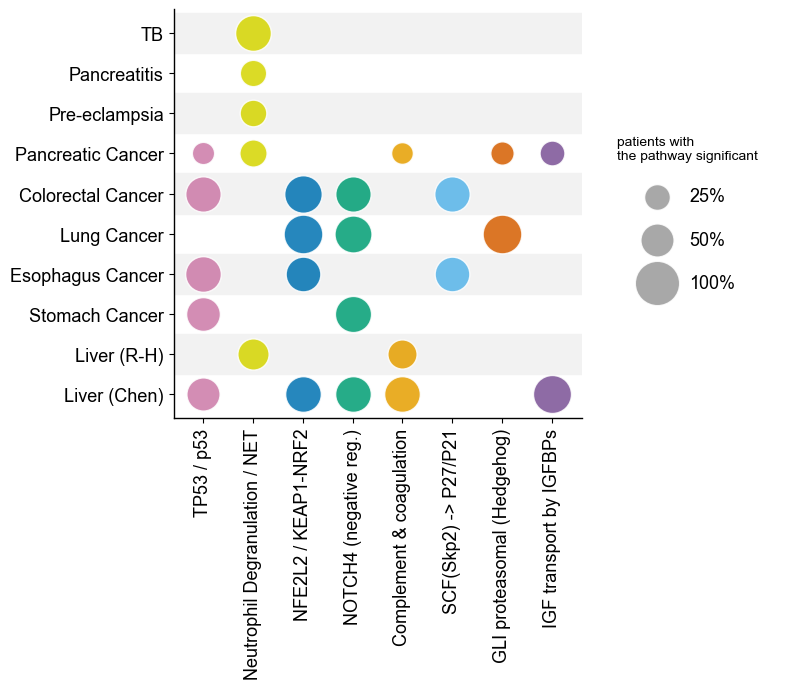

In [13]:
def parse_selected_with_stats(md_path):
    # ("### N. Name" heading, "n_sig=X/N, size=..., eff=..." line right below it) pairs
    lines = open(md_path).read().splitlines()
    out, in_section, cur_name = [], False, None
    for line in lines:
        if line.strip().startswith('## '):
            in_section = line.strip().lstrip('#').strip().lower() == 'selected pathways'
            continue
        if not in_section:
            continue
        m = re.match(r'^###\s*(?:\d+\.\s*)?(.+?)\s*$', line.strip())
        if m:
            cur_name = m.group(1)
            continue
        m2 = re.match(r'^n_sig=(\d+)/(\d+)', line.strip())
        if m2 and cur_name:
            out.append((cur_name, int(m2.group(1)), int(m2.group(2))))
            cur_name = None
    return out


PHENOTYPE_ORDER = ['Tuberculosis', 'Pancreatitis', 'Pre-eclampsia', 'Pancreatic Cancer',
                  'Colorectal Cancer', 'Lung Cancer', 'Esophagus Cancer', 'Stomach Cancer',
                  'Liver Cancer (Roskams-Hieter B et al.)', 'Liver Cancer (Chen et al.)']
PHENOTYPE_SHORT = {'Tuberculosis': 'TB', 'Pancreatitis': 'Pancreatitis', 'Pre-eclampsia': 'Pre-eclampsia',
                   'Pancreatic Cancer': 'Pancreatic Cancer', 'Colorectal Cancer': 'Colorectal Cancer',
                   'Lung Cancer': 'Lung Cancer', 'Esophagus Cancer': 'Esophagus Cancer',
                   'Stomach Cancer': 'Stomach Cancer', 'Liver Cancer (Roskams-Hieter B et al.)': 'Liver (R-H)',
                   'Liver Cancer (Chen et al.)': 'Liver (Chen)'}

# All eight cross-phenotype modules. Regexes verified against the `## Selected pathways`
# headings of every PathwayConvergence/*/pathway_literature_review.md.
MODULES = [
    ('NFE2L2 / KEAP1-NRF2', re.compile(r'NFE2L2|KEAP1', re.IGNORECASE), '#0072B2'),
    ('NOTCH4 (negative reg.)', re.compile(r'NOTCH4', re.IGNORECASE), '#009E73'),
    ('TP53 / p53', re.compile(r'\bp53\b|TP53', re.IGNORECASE), '#CC79A7'),
    ('Neutrophil Degranulation / NET', re.compile(r'Neutrophil Degranulation|Neutrophil.{0,3}[Ee]xtracellular.{0,3}[Tt]rap|NET [Ff]ormation', re.IGNORECASE), '#D5D500'),
    ('Complement & coagulation', re.compile(r'Complement and coagulation', re.IGNORECASE), '#E69F00'),
    ('SCF(Skp2) -> P27/P21', re.compile(r'SCF\(Skp2\)|Skp2', re.IGNORECASE), '#56B4E9'),
    ('GLI proteasomal (Hedgehog)', re.compile(r'\bGLI[0-9]?R?\b|Hedgehog', re.IGNORECASE), '#D55E00'),
    ('IGF transport by IGFBPs', re.compile(r'IGFBP', re.IGNORECASE), '#7A5195'),
]

rows = []
for ph in PHENOTYPE_ORDER:
    review_path = PCDIR / slugify(ph) / 'pathway_literature_review.md'
    if not review_path.exists():
        continue
    selected = parse_selected_with_stats(review_path)
    for mod_name, rx, color in MODULES:
        hits = [(name, n, tot) for name, n, tot in selected if rx.search(name)]
        if hits:
            name, n, tot = max(hits, key=lambda h: h[1] / h[2])
            rows.append(dict(phenotype=ph, module=mod_name, matched_name=name, rate=n / tot, color=color))
recur = pd.DataFrame(rows)
print(recur[['phenotype', 'module', 'matched_name', 'rate']].to_string(index=False))

# x = module (ordered by how many phenotypes it recurs in), y = phenotype
mod_n = recur.groupby('module')['phenotype'].nunique()
mod_order = [m for m, _, _ in sorted(MODULES, key=lambda t: -mod_n.get(t[0], 0))]
mod_order = [m for m in mod_order if m in mod_n.index]

fig, ax = plt.subplots(figsize=(8, 7))
x_pos = {m: i for i, m in enumerate(mod_order)}
y_pos = {ph: i for i, ph in enumerate(PHENOTYPE_ORDER)}
for i in range(len(PHENOTYPE_ORDER)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='#f2f2f2', zorder=0)
for _, r in recur.iterrows():
    ax.scatter(x_pos[r.module], y_pos[r.phenotype], s=120 + 900 * r.rate,
               facecolor=r.color, edgecolor='white', linewidths=1, zorder=2, alpha=0.85)
ax.set_xticks(range(len(mod_order)))
ax.set_xticklabels(mod_order, rotation=90)
ax.set_yticks(range(len(PHENOTYPE_ORDER)))
ax.set_yticklabels([PHENOTYPE_SHORT[p] for p in PHENOTYPE_ORDER])
ax.set_xlim(-0.6, len(mod_order) - 0.4)
ax.set_ylim(-0.6, len(PHENOTYPE_ORDER) - 0.4)
ax.invert_yaxis()
# bubble area encodes the within-cohort recurrence rate (n_sig / n_patients)
for rate in (0.25, 0.5, 1.0):
    ax.scatter([], [], s=120 + 900 * rate, facecolor='#999999', edgecolor='white',
               linewidths=1, alpha=0.85, label=f'{rate:.0%}')
ax.legend(title='patients with\nthe pathway significant', loc='center left',
          bbox_to_anchor=(1.02, 0.5), frameon=False, labelspacing=1.4, borderpad=1)
plt.tight_layout()
plt.savefig(PFDIR / 'cross_phenotype_module_recurrence.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
TOP_GENES_PER_MODULE = 30  # visibility cap -- keep only the strongest genes per module

PHENOTYPE_CATEGORY = {
    'Tuberculosis': 'Inflammatory', 'Pancreatitis': 'Inflammatory', 'Pre-eclampsia': 'Inflammatory',
    'Pancreatic Cancer': 'Cancer', 'Colorectal Cancer': 'Cancer', 'Lung Cancer': 'Cancer',
    'Esophagus Cancer': 'Cancer', 'Stomach Cancer': 'Cancer',
    'Liver Cancer (Roskams-Hieter B et al.)': 'Cancer', 'Liver Cancer (Chen et al.)': 'Cancer',
}
CATEGORY_CMAP = {'Cancer': plt.get_cmap('Reds'), 'Inflammatory': plt.get_cmap('Blues')}
PHENOTYPE_COLORS = {}
for cat, phs in [('Cancer', [p for p in PHENOTYPE_ORDER if PHENOTYPE_CATEGORY[p] == 'Cancer']),
                 ('Inflammatory', [p for p in PHENOTYPE_ORDER if PHENOTYPE_CATEGORY[p] == 'Inflammatory'])]:
    shades = np.linspace(0.45, 0.9, len(phs))
    for ph, s in zip(phs, shades):
        PHENOTYPE_COLORS[ph] = f'#{"".join(f"{int(c * 255):02x}" for c in CATEGORY_CMAP[cat](s)[:3])}'

mod_color = {m: c for m, _, c in MODULES}


def tint(hex_str, amount=0.55):
    r, g, b = (int(hex_str.lstrip('#')[k:k + 2], 16) / 255 for k in (0, 2, 4))
    r, g, b = (v + (1 - v) * amount for v in (r, g, b))
    return f'#{int(r * 255):02x}{int(g * 255):02x}{int(b * 255):02x}'


gene_tint = {m: tint(c) for m, c in mod_color.items()}

pat_gene_z, gene_module_z = {}, {}
for _, r in recur.iterrows():
    slug = slugify(r.phenotype)
    d = pickle.load(open(PCDIR / slug / 'sig.pkl', 'rb'))
    Zu, Fm = pickle.load(open(PCDIR / slug / 'universe.pkl', 'rb'))
    j = match_pathway_index(r.matched_name, d['terms'])
    if j is None:
        continue
    members = np.where(M[j])[0]
    pats = np.where(d['path_sig'][:, j])[0]
    if len(pats) == 0 or len(members) == 0:
        continue
    sub = Zu[np.ix_(pats, members)]
    qual = np.abs(sub) >= EDGE_Z_MIN
    gcols_all = np.where(qual.any(axis=0))[0]
    if len(gcols_all) == 0:
        continue
    deg = qual[:, gcols_all].sum(axis=0)
    strength = np.where(qual[:, gcols_all], np.abs(sub[:, gcols_all]), 0).sum(axis=0)
    ranked = gcols_all[np.lexsort((-strength, -deg))]
    gcols, family_count = [], {}
    for gc in ranked:
        fam = gene_family(universe_syms[members[gc]])
        if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
            continue
        gcols.append(gc)
        family_count[fam] = family_count.get(fam, 0) + 1
        if len(gcols) == MAX_GENES_PER_PATHWAY:
            break
    for gc in gcols:
        gu = members[gc]
        gene_key = (r.module, universe_syms[gu])
        for k in range(len(pats)):
            z = sub[k, gc]
            if abs(z) < EDGE_Z_MIN:
                continue
            pat_key = f'{r.phenotype}:{pats[k]}'
            pat_gene_z[(pat_key, gene_key)] = max(pat_gene_z.get((pat_key, gene_key), 0), abs(z))
            gene_module_z[(gene_key, r.module)] = gene_module_z.get((gene_key, r.module), 0) + abs(z)

# visibility: keep only the TOP_GENES_PER_MODULE strongest genes per module
keep_genes = set()
for module in {m for _, m in gene_module_z}:
    ranked = sorted([g for g, m in gene_module_z if m == module], key=lambda g: -gene_module_z[(g, module)])
    keep_genes.update(ranked[:TOP_GENES_PER_MODULE])
pat_gene_z = {k: v for k, v in pat_gene_z.items() if k[1] in keep_genes}
gene_module_z = {k: v for k, v in gene_module_z.items() if k[0] in keep_genes}

displayed_pats = sorted({p for p, _ in pat_gene_z})
displayed_genes = sorted({g for _, g in pat_gene_z})
modules = [m for m, _, _ in MODULES if any(g[0] == m for g in displayed_genes)]

nodes = displayed_pats + [g[1] for g in displayed_genes] + modules
idx = {n: i for i, n in enumerate(displayed_pats)}
idx.update({g: len(displayed_pats) + i for i, g in enumerate(displayed_genes)})
idx.update({m: len(displayed_pats) + len(displayed_genes) + i for i, m in enumerate(modules)})

node_colors = ([PHENOTYPE_COLORS[p.split(':')[0]] for p in displayed_pats]
              + [gene_tint[g[0]] for g in displayed_genes]
              + [mod_color[m] for m in modules])

src, tgt, val, link_col = [], [], [], []
for (pat_key, gene_key), z in pat_gene_z.items():
    src.append(idx[pat_key]); tgt.append(idx[gene_key]); val.append(z)
    link_col.append(hex_to_rgba(PHENOTYPE_COLORS[pat_key.split(':')[0]], 0.35))
for (gene_key, module), z in gene_module_z.items():
    src.append(idx[gene_key]); tgt.append(idx[module]); val.append(z)
    link_col.append(hex_to_rgba(mod_color[module], 0.45))

node_labels = displayed_pats + [g[1] for g in displayed_genes] + modules
fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, color=node_colors, pad=3, thickness=10, line=dict(width=0)),
    link=dict(source=src, target=tgt, value=val, color=link_col),
))
fig.update_layout(width=1000, height=max(900, len(displayed_pats) * 10), font_size=10,
                  title='Patient -> pathway-member gene -> pathway module (all cohorts)')

# plotly.js hardcodes a white text-shadow halo on Sankey node labels -- strip it via SVG post-process
svg = fig.to_image(format='svg').decode('utf-8')
svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
out_path = PFDIR / 'cross_phenotype_sankey.png'
cairosvg.svg2png(bytestring=svg.encode('utf-8'), write_to=str(out_path), scale=2)
fig.show()
print(f'{len(displayed_pats)} patients, {len(displayed_genes)} genes, {len(modules)} modules -> {out_path}')

/tmp/ipykernel_58688/3234486921.py:107: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


216 patients, 214 genes, 8 modules -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/cross_phenotype_sankey.png
